     부서    기본급         성과급    수당
0   개발팀  300.0  100.000000  50.0
1  마케팅팀  250.0   70.000000  40.0
2   영업팀  250.0   80.000000  40.0
3   인사팀  200.0   83.333333  30.0


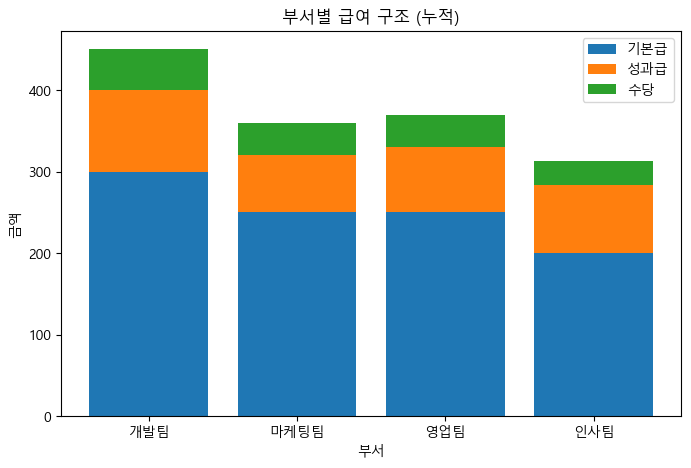

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# 1. 데이터 생성
# ---------------------------
df1 = pd.DataFrame({
    "부서": ["개발팀", "영업팀", "인사팀"],
    "기본급": [300, 250, 200]
})

df2 = pd.DataFrame({
    "부서": ["개발팀", "영업팀", "마케팅팀"],
    "성과급": [100, 80, 70]
})

#추가 데이터 (3번째)
df3 = pd.DataFrame({
    "부서": ["개발팀", "영업팀", "인사팀"],
    "수당": [50, 40, 30]
})

# ---------------------------
# 2. 데이터 병합
# ---------------------------
merged = pd.merge(df1, df2, on="부서", how="outer")
merged = pd.merge(merged, df3, on="부서", how="outer")

# ---------------------------
# 3. 결측치 처리 (평균)
# ---------------------------
merged["기본급"] = merged["기본급"].fillna(merged["기본급"].mean())
merged["성과급"] = merged["성과급"].fillna(merged["성과급"].mean())
merged["수당"] = merged["수당"].fillna(merged["수당"].mean())

print(merged)

# ---------------------------
# 4. 그래프 설정
# ---------------------------
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 5))

# ---------------------------
# 5. 누적 막대 그래프
# ---------------------------

# ① 기본급 (맨 아래)
plt.bar(merged["부서"], merged["기본급"], label="기본급")

# ② 성과급 (기본급 위)
plt.bar(
    merged["부서"],
    merged["성과급"],
    bottom=merged["기본급"],
    label="성과급"
)

# ③ 수당 (기본급 + 성과급 위)
plt.bar(
    merged["부서"],
    merged["수당"],
    bottom=merged["기본급"] + merged["성과급"],  # 핵심!
    label="수당"
)

# ---------------------------
# 6. 그래프 꾸미기
# ---------------------------
plt.title("부서별 급여 구조 (누적)")
plt.xlabel("부서")
plt.ylabel("금액")

plt.legend()

# ---------------------------
# 7. 저장 및 출력
# ---------------------------
plt.savefig("salary_chart.png", dpi=300)
plt.show()

     부서    기본급         성과급    수당        실수령액
0   개발팀  300.0  100.000000  50.0  450.000000
1  마케팅팀  250.0   70.000000  40.0  360.000000
2   영업팀  250.0   80.000000  40.0  370.000000
3   인사팀  200.0   83.333333  30.0  313.333333


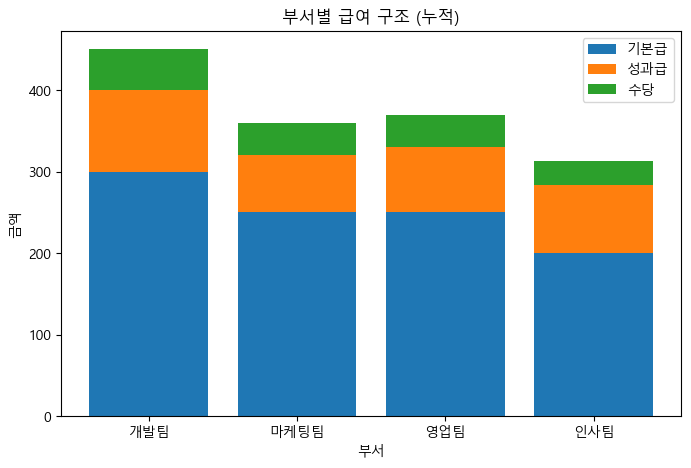

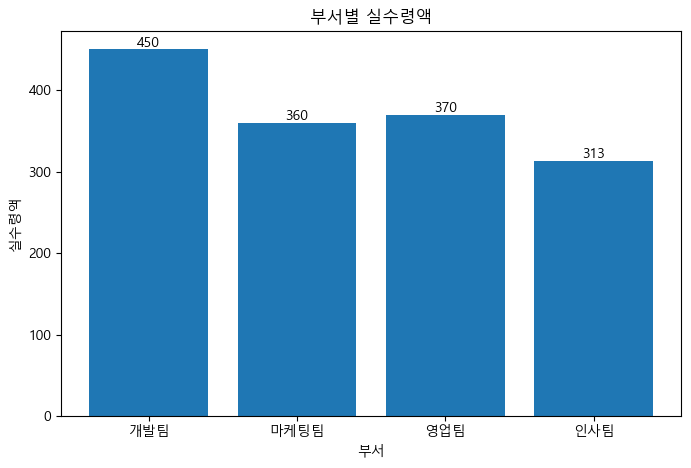

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# 1. 데이터 생성
# ---------------------------
df1 = pd.DataFrame({
    "부서": ["개발팀", "영업팀", "인사팀"],
    "기본급": [300, 250, 200]
})

df2 = pd.DataFrame({
    "부서": ["개발팀", "영업팀", "마케팅팀"],
    "성과급": [100, 80, 70]
})

df3 = pd.DataFrame({
    "부서": ["개발팀", "영업팀", "인사팀"],
    "수당": [50, 40, 30]
})

# ---------------------------
# 2. 데이터 병합 (outer join)
# ---------------------------
merged = pd.merge(df1, df2, on="부서", how="outer")
merged = pd.merge(merged, df3, on="부서", how="outer")

# ---------------------------
# 3. 결측치 처리 (평균값)
# ---------------------------
merged["기본급"] = merged["기본급"].fillna(merged["기본급"].mean())
merged["성과급"] = merged["성과급"].fillna(merged["성과급"].mean())
merged["수당"] = merged["수당"].fillna(merged["수당"].mean())

# ---------------------------
# 4. 실수령액 컬럼 생성 ⭐
# ---------------------------
merged["실수령액"] = merged["기본급"] + merged["성과급"] + merged["수당"]

print(merged)

# ---------------------------
# 5. 그래프 설정
# ---------------------------
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ---------------------------
# 6. 누적 막대 그래프
# ---------------------------
plt.figure(figsize=(8, 5))

plt.bar(merged["부서"], merged["기본급"], label="기본급")

plt.bar(
    merged["부서"],
    merged["성과급"],
    bottom=merged["기본급"],
    label="성과급"
)

plt.bar(
    merged["부서"],
    merged["수당"],
    bottom=merged["기본급"] + merged["성과급"],
    label="수당"
)

plt.title("부서별 급여 구조 (누적)")
plt.xlabel("부서")
plt.ylabel("금액")
plt.legend()

plt.show()

# ---------------------------
# 7. 실수령액 그래프 ⭐
# ---------------------------
plt.figure(figsize=(8, 5))

plt.bar(merged["부서"], merged["실수령액"])

plt.title("부서별 실수령액")
plt.xlabel("부서")
plt.ylabel("실수령액")

# 값 표시 (수업용 핵심 포인트)
for i in range(len(merged["실수령액"])):
    v = merged["실수령액"][i]
    plt.text(i, v, int(v), ha='center', va='bottom')

plt.show()